In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

c:\Users\welcome\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\welcome\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [5]:
import pandas as pd
import numpy as np
import os
print(os.listdir(path))

['creditcard.csv']


In [6]:
file_path=os.path.join(
    path,
    'creditcard.csv')
df=pd.read_csv(file_path)

In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Task 1: Business Understanding
Students must answer:
Why is fraud detection difficult?
Why is accuracy alone misleading?


Task 2: Exploratory Analysis

Find:

Fraud %

Legitimate %

Class imbalance ratio

Visualizations:

Transaction Amount Distribution

Fraud vs Non-Fraud

Correlation Heatmap


In [8]:
df.shape

(284807, 31)

In [9]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [10]:
#fraud percentage
fraud_percent=(df['Class'].value_counts()[1])/len(df)*100
print(fraud_percent)

0.1727485630620034


In [11]:
legit_precent=(df['Class'].value_counts()[0])/len(df)*100
print(legit_precent)

99.82725143693798


In [12]:
#imbalance ratio
imbalance_ratio=df['Class'].value_counts()[0]/df['Class'].value_counts()[1]
print(imbalance_ratio)

577.8760162601626


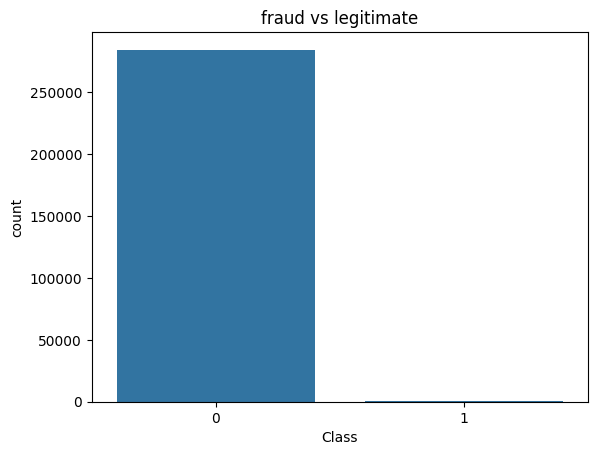

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(
    x='Class',
    data=df
)
plt.title("fraud vs legitimate")
plt.show()

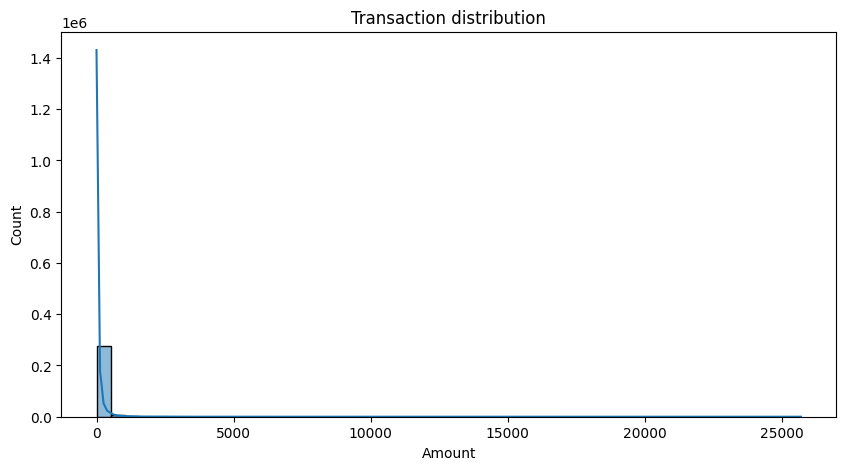

In [14]:
#transaction amount distribution
plt.figure(figsize=(10,5))
sns.histplot(
    df['Amount'],
    bins=50,
    kde=True
)
plt.title("Transaction distribution")
plt.show()

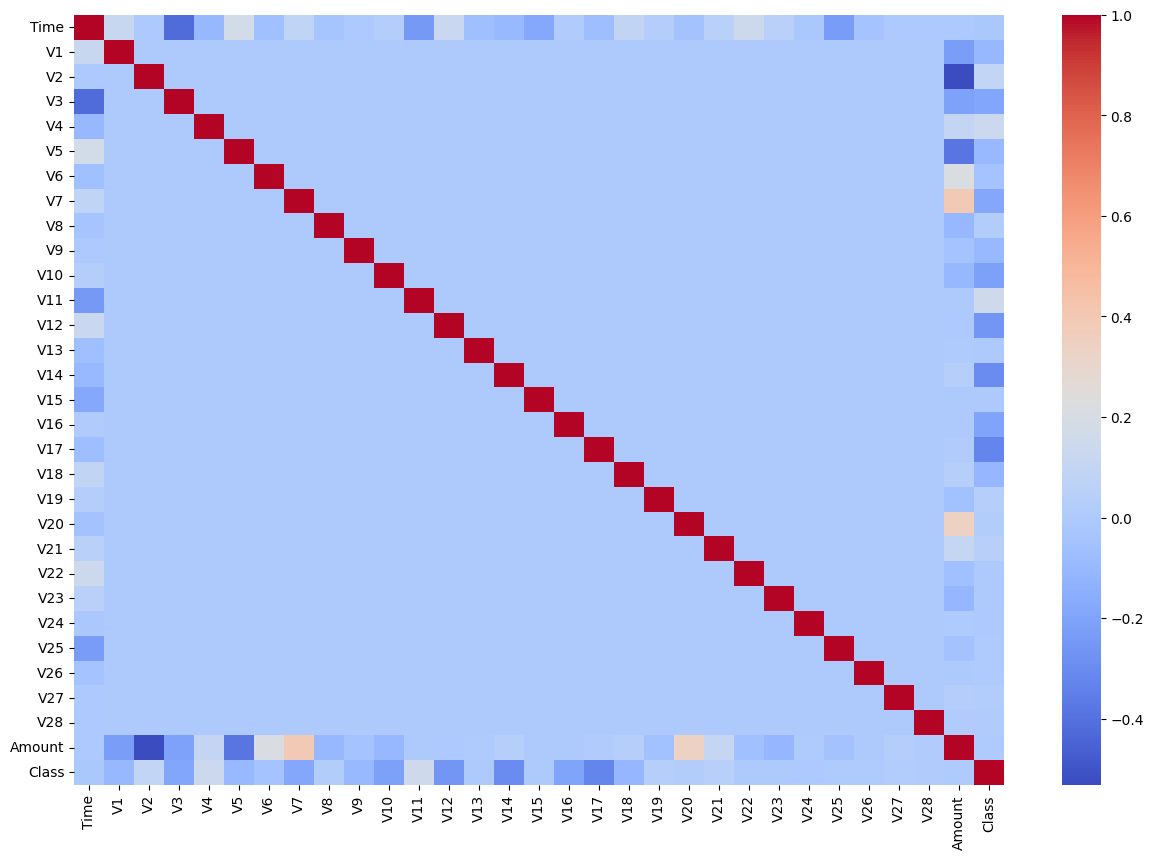

In [15]:
#heat map
plt.figure(figsize=(15,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm'
)

plt.show()

Task 3: Sequence Generation

Create customer transaction sequences.

Example:

Txn1

Txn2

Txn3

Txn4

↓

Predict Txn5 Fraud?


In [16]:
import numpy as np

df = df.sort_values("Time")

sequence_length = 5

X_seq = []
y_seq = []

for i in range(len(df) - sequence_length):
    seq = df.iloc[i:i+sequence_length].drop(columns=['Class']).values
    label = df.iloc[i+sequence_length]['Class']

    X_seq.append(seq)
    y_seq.append(label)

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print(X_seq.shape, y_seq.shape)

(284802, 5, 30) (284802,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

dense_model = Sequential([
    Flatten(input_shape=(5, 30)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

dense_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

dense_model.fit(X_seq, y_seq, epochs=5, batch_size=32)  

Epoch 1/5


8901/8901 [==============================] - 38s 4ms/step - loss: 7.7638 - accuracy: 0.9962
Epoch 2/5
8901/8901 [==============================] - 45s 5ms/step - loss: 0.8667 - accuracy: 0.9967
Epoch 3/5
8901/8901 [==============================] - 55s 6ms/step - loss: 0.0571 - accuracy: 0.9983
Epoch 4/5
8901/8901 [==============================] - 60s 7ms/step - loss: 0.0133 - accuracy: 0.9983
Epoch 5/5
8901/8901 [==============================] - 58s 7ms/step - loss: 0.0130 - accuracy: 0.9983


In [18]:
from tensorflow.keras.layers import LSTM, Input
from tensorflow.keras.models import Model

inp = Input(shape=(5, 30))

x = LSTM(64)(inp)

x = Dense(32, activation='relu')(x)

out = Dense(1, activation='sigmoid')(x)

lstm_model = Model(inp, out)

lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

lstm_model.fit(X_seq, y_seq, epochs=5, batch_size=32)

Epoch 1/5
8901/8901 [==============================] - 104s 11ms/step - loss: 0.0151 - accuracy: 0.9978
Epoch 2/5
8901/8901 [==============================] - 107s 12ms/step - loss: 0.0129 - accuracy: 0.9983
Epoch 3/5
8901/8901 [==============================] - 66s 7ms/step - loss: 0.0129 - accuracy: 0.9983
Epoch 4/5
8901/8901 [==============================] - 86s 10ms/step - loss: 0.0129 - accuracy: 0.9983
Epoch 5/5
8901/8901 [==============================] - 105s 12ms/step - loss: 0.0128 - accuracy: 0.9983


In [19]:
from tensorflow.keras.layers import MultiHeadAttention

inp = Input(shape=(5, 30))

x = LSTM(64, return_sequences=True)(inp)

x = MultiHeadAttention(num_heads=2, key_dim=16)(x, x)

x = Flatten()(x)

x = Dense(32, activation='relu')(x)

out = Dense(1, activation='sigmoid')(x)

att_model = Model(inp, out)

att_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
att_model.fit(X_seq, y_seq, epochs=5, batch_size=32)

Epoch 1/5
8901/8901 [==============================] - 116s 12ms/step - loss: 0.0143 - accuracy: 0.9983
Epoch 2/5
8901/8901 [==============================] - 104s 12ms/step - loss: 0.0134 - accuracy: 0.9983
Epoch 3/5
8901/8901 [==============================] - 97s 11ms/step - loss: 0.0133 - accuracy: 0.9983
Epoch 4/5
8901/8901 [==============================] - 98s 11ms/step - loss: 0.0132 - accuracy: 0.9983
Epoch 5/5
8901/8901 [==============================] - 92s 10ms/step - loss: 0.0131 - accuracy: 0.9983


In [20]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, MultiHeadAttention
from tensorflow.keras.models import Model

inp = Input(shape=(5, 30))

x = LSTM(64, return_sequences=True)(inp)

x = MultiHeadAttention(num_heads=2, key_dim=16)(x, x)

x = Dense(32, activation='relu')(x)

out = Dense(1, activation='sigmoid')(x)

model = Model(inp, out)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

def positional_encoding(position, d_model):
    pos = np.arange(position)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]

    angle = pos / np.power(10000, (2*(i//2))/np.float32(d_model))

    pe = np.zeros((position, d_model))
    pe[:, 0::2] = np.sin(angle[:, 0::2])
    pe[:, 1::2] = np.cos(angle[:, 1::2])

    return tf.cast(pe, tf.float32)

PE = positional_encoding(5, 30)

Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 5, 30)]              0         []                            
                                                                                                  
 lstm_3 (LSTM)               (None, 5, 64)                24320     ['input_4[0][0]']             
                                                                                                  
 multi_head_attention_2 (Mu  (None, 5, 64)                8352      ['lstm_3[0][0]',              
 ltiHeadAttention)                                                   'lstm_3[0][0]']              
                                                                                                  
 dense_9 (Dense)             (None, 5, 32)                2080      ['multi_head_attention_2

In [21]:
sample = X_seq[:1]

pred = att_model.predict(sample)
print("Fraud Probability:", pred)

1/1 [==============================] - 2s 2s/step
Fraud Probability: [[0.00091839]]


In [22]:
import joblib
import tensorflow as tf
import numpy as np

# Save model
att_model.save("fraud_model.h5")

# If you used any scaler (optional)
# joblib.dump(scaler, "scaler.pkl")

# Save any metadata if needed
joblib.dump(sequence_length, "seq_len.pkl")

print("Model saved successfully")

Model saved successfully


c:\Users\welcome\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
